## **Gradiente Descendente Estocástico**

O SGD não utiliza todos os dados presentes no dataset para o cálculo do gradiente, mas sim um pequeno subconjunto dos dados.

Considere o dataset:

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}
\quad \text{onde }
\mathbf{x}_i \in \mathbb{R}^{D}
\text{ e }
y_i \in \mathbb{R}
$$

No SGD, escolhe-se de forma aleatória um índice:

$$
i_t \sim \mathcal{U}\{1,2,\ldots,N\}
$$

e, ao invés de calcular o gradiente completo (como ocorre no GD), utiliza-se apenas o gradiente da perda individual $L_{i_t}(\mathbf{w})$:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \cdot \nabla L_{i_t}\!\left(\mathbf{w}^{(t)}\right)
$$

onde $\nabla L_{i_t}(\mathbf{w})$ é um **estimador não-viesado** do gradiente completo $\nabla J(\mathbf{w})$:

$$
\mathbb{E}\!\left[\nabla L_{i_t}(\mathbf{w})\right] = \nabla J(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^{N} \nabla L_i(\mathbf{w})
$$


#### **Mini-Batch**

Na prática, utiliza-se um subconjunto pequeno de amostras, chamado de **mini-batch**, $B_t$.

O mini-batch é um conjunto de índices, amostrado aleatoriamente a cada iteração $t$:

$$
B_t \subset \{1,2,\ldots,N\}, \qquad |B_t| = M, \quad 1 \le M < N
$$

O gradiente é então estimado pela média das perdas individuais sobre os índices de $B_t$:

$$
\nabla J_{B_t}(\mathbf{w}) = \frac{1}{M} \sum_{i \in B_t} \nabla L_i(\mathbf{w})
$$

e a regra de atualização do SGD com mini-batch é:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \cdot \frac{1}{M} \sum_{i \in B_t} \nabla L_i\!\left(\mathbf{w}^{(t)}\right)
$$

Note que este estimador também é não-viesado, ou seja:

$$\mathbb{E}\!\left[\nabla J_{B_t}(\mathbf{w})\right] = \nabla J(\mathbf{w})$$.


> GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning. Cambridge: MIT Press, 2016. Seção 5.9, p. 151.

> GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning. Cambridge: MIT Press, 2016. Seção 8.1.3, p. 277.

## **Aplicação do Gradiente Descendente Estocástico**

Vamos aplicar o método do GDE para tarefa de **regressão** usando **Regressão Linear** no dataset [**California Housing**](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html).

### **Pré-processamento dos dados**

#### **Dataset**

In [53]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (20640, 8)
Shape de y: (20640,)


In [54]:
import pandas as pd

df = pd.DataFrame(X, columns=housing.feature_names)
df["target"] = y

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


#### **Divisão do dataset nos conjuntos de treino e validação**

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (16512, 8)
Teste: (4128, 8)


#### **Padronização dos dados (z-score)**

In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **Adicionando intercepto na matriz $\mathbf{X}$**

In [57]:
import numpy as np

def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (16512, 9)
Teste: (4128, 9)


### **Implementação do SGD e da Regressão Linear**

A Regressão Linear utiliza como função objetivo o **MSE (Mean Squared Error)**:

$$
J(\mathbf{w}) = \frac{1}{N}\sum_{i=1}^{N} L_i(\mathbf{w})
\quad \text{onde} \quad
L_i(\mathbf{w}) = \left(\mathbf{x}_i^{\top}\mathbf{w} - y_i\right)^{2}
$$

O gradiente da perda individual é:

$$
\nabla L_i(\mathbf{w}) = 2\left(\mathbf{x}_i^{\top}\mathbf{w} - y_i\right)\mathbf{x}_i
$$

Portanto, a regra de atualização do SGD com mini-batch de tamanho $M = |B_t|$:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \cdot \frac{2}{M} \sum_{i \in B_t} \left(\mathbf{x}_i^{\top}\mathbf{w}^{(t)} - y_i\right)\mathbf{x}_i
$$

> GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. Deep Learning. Cambridge: MIT Press, 2016. Seção 5.9, p. 151.

### **Implementando o SGD com Mini-Batch**

In [58]:
def predict(X, w):
    return X @ w

def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def train_gde_mini_batch(X, y, w, eta=0.01, epochs=100, batch_size=32):

    n_samples = X.shape[0]
    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(n_samples)

        for start in range(0, n_samples, batch_size):

            batch_idx = indices[start:start+batch_size]

            Xb = X[batch_idx]
            yb = y[batch_idx]

            error = Xb @ w - yb

            gradient = (Xb @ w - yb) @ Xb

            w = w - eta * (2 / len(batch_idx)) * gradient

        y_epoch_pred = predict(X, w)
        loss = mse(y, y_epoch_pred)

        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")

    return w, loss_history

### **Treino e Validação**

#### **Métricas de Validação**

In [59]:
from sklearn.metrics import mean_absolute_error, r2_score

def regression_report(y_true, y_pred):
    _mse  = mse(y_true, y_pred)
    print(f"MSE:  {_mse:.4f}")
    print(f"RMSE: {np.sqrt(_mse):.4f}")
    print(f"MAE:  {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"R²:   {r2_score(y_true, y_pred):.4f}")

#### **Treino**

In [60]:
w = np.random.randn(X_train.shape[1])

w, loss_history = train_gde_mini_batch(
    X_train,
    y_train,
    w,
    epochs=100,
    eta = 0.005,
    batch_size=32
)

Epoch 0 | Loss: 0.7805
Epoch 10 | Loss: 0.5224
Epoch 20 | Loss: 0.5239
Epoch 30 | Loss: 0.5199
Epoch 40 | Loss: 0.5185
Epoch 50 | Loss: 0.5186
Epoch 60 | Loss: 0.5202
Epoch 70 | Loss: 0.5203
Epoch 80 | Loss: 0.5184
Epoch 90 | Loss: 0.5191


#### **Valor de $\mathbf{w}$ ótimo**

In [61]:
for i, b in enumerate(w.flatten()):
    print(f"w{i}: {b:.4f}")

w0: 2.0614
w1: 0.8442
w2: 0.1221
w3: -0.3039
w4: 0.3264
w5: 0.0007
w6: -0.0240
w7: -0.8939
w8: -0.8735


#### **Curva de Aprendizado**

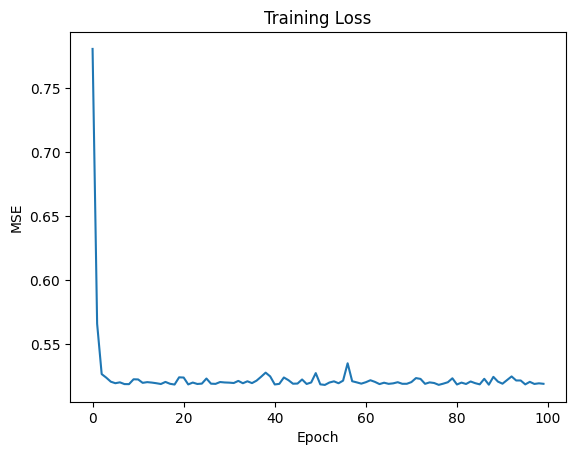

In [62]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training Loss")
plt.show()

#### **Validação**

In [63]:
y_pred = predict(X_test, w)

#### **Métricas**

In [64]:
regression_report(y_test, y_pred)

MSE:  0.5505
RMSE: 0.7420
MAE:  0.5328
R²:   0.5799


### **Visualização dos dados com PCA**

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)

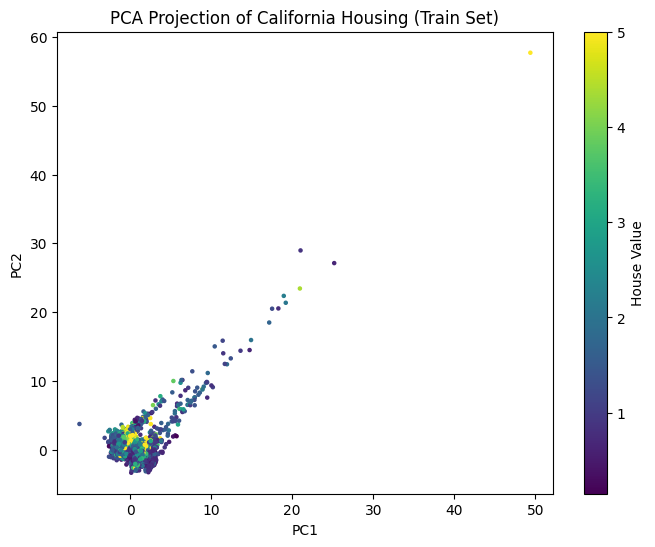

In [67]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_train_pca[:,0],
    X_train_pca[:,1],
    c=y_train,
    cmap="viridis",
    s=5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection of California Housing (Train Set)")
plt.colorbar(label="House Value")

plt.show()